# Irrotational & Solenoidal Fields: Griffiths' Two Theorems, Three Ways

Griffiths states two identities early and uses them constantly:
$$\nabla\times(\nabla f)=0 \quad\text{(curl of a gradient is always zero)}, \qquad
\nabla\cdot(\nabla\times\mathbf A)=0 \quad\text{(divergence of a curl is always zero)}.$$

Made concrete with the two symmetric fields Griffiths himself reaches for:

- **Irrotational**: $\mathbf E\sim\hat{\mathbf r}/r^2$ (a point charge's
  field direction) is $-\nabla(1/r)$ -- a pure gradient, so its curl is
  zero automatically.
- **Solenoidal**: $\mathbf B\sim\hat{\boldsymbol\phi}/s$ (an infinite
  wire's field direction) is $\nabla\times(-\ln(s)\hat{\mathbf z})$ -- a
  pure curl, so its divergence is zero automatically.

Each claim is proven exactly with SymPy, then cross-checked by two
independent NUMERICAL methods -- torch autograd (exact Jacobians) and a
from-scratch C program (finite differences) -- same polyglot
cross-validation posture as `dgs.circuits_polyglot`. A genuine subtlety
closes the notebook: the wire's $\mathbf B$ has zero curl everywhere away
from the wire, yet a nonzero circulation around any loop enclosing it.
Engine: `dgs/irrotational_solenoidal_polyglot.py`.


In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

from dgs import irrotational_solenoidal_polyglot as isp

print('Setup complete.')


Setup complete.


## 1. SymPy: Both Theorems, Made Concrete and Exact


In [2]:
irr = isp.irrotational_field_proof()
print('IRROTATIONAL (E ~ rhat/r^2):')
print(f"  E == -grad(1/r):  {irr['is_gradient_of_minus_1_over_r']}")
print(f"  curl(E) == 0:     {irr['curl_is_zero']}")

sol = isp.solenoidal_field_proof()
print('\nSOLENOIDAL (B ~ phihat/s):')
print(f"  B == curl(-ln(s) zhat): {sol['is_curl_of_vector_potential']}")
print(f"  div(B) == 0:            {sol['div_is_zero']}")
print(f"  curl(B) == 0 (away from the wire): {sol['curl_is_zero_away_from_wire']}")


IRROTATIONAL (E ~ rhat/r^2):
  E == -grad(1/r):  True
  curl(E) == 0:     True

SOLENOIDAL (B ~ phihat/s):
  B == curl(-ln(s) zhat): True
  div(B) == 0:            True
  curl(B) == 0 (away from the wire): True


## 2. Torch: Autograd-Exact Pointwise Checks

`torch_div_curl_at_points` computes the EXACT Jacobian (via
`torch.func.jacrev`+`vmap`, no finite-difference step size) at sampled
points, then extracts divergence (trace) and curl (antisymmetric part).


In [3]:
try:
    import torch
    HAVE_TORCH = True
except ImportError:
    HAVE_TORCH = False
    print('torch not available in this kernel -- run under py 3.12 for this section')

if HAVE_TORCH:
    rng = np.random.default_rng(0)
    irr_pts = rng.uniform(-3, 3, size=(500, 3))
    irr_pts = irr_pts[np.linalg.norm(irr_pts, axis=1) > 0.5]
    irr_check = isp.torch_div_curl_at_points('irrotational', irr_pts)
    print(f"irrotational field: max|curl| over {len(irr_pts)} points = {np.max(np.abs(irr_check['curl'])):.3e}")

    sol_pts = rng.uniform(-3, 3, size=(500, 3))
    s = np.linalg.norm(sol_pts[:, :2], axis=1)
    sol_pts = sol_pts[s > 0.5]
    sol_check = isp.torch_div_curl_at_points('solenoidal', sol_pts)
    print(f"solenoidal field:   max|div|  over {len(sol_pts)} points = {np.max(np.abs(sol_check['divergence'])):.3e}")
    print(f"solenoidal field:   max|curl| over {len(sol_pts)} points = {np.max(np.abs(sol_check['curl'])):.3e}")


irrotational field: max|curl| over 500 points = 4.441e-16
solenoidal field:   max|div|  over 488 points = 4.441e-16
solenoidal field:   max|curl| over 488 points = 8.882e-16


## 3. C: Independent Finite-Difference Cross-Check

`cross_validate_languages` compiles and runs a from-scratch C program
(central finite differences) at the same points, and compares against
torch's exact values -- requires `gcc`, skipped gracefully if not found.


In [4]:
import os

HAVE_GCC = os.path.exists(isp.GCC_DEFAULT)
if HAVE_GCC:
    import tempfile
    with tempfile.TemporaryDirectory() as tmp:
        result = isp.cross_validate_languages(tmp)
    for kind, r in result.items():
        print(f"{kind}: max|torch-C| divergence = {r['max_abs_diff_divergence']:.3e}, "
              f"curl = {r['max_abs_diff_curl']:.3e}")
else:
    print('gcc not found at', isp.GCC_DEFAULT, '-- section skipped')


irrotational: max|torch-C| divergence = 1.457e-11, curl = 1.582e-10
solenoidal: max|torch-C| divergence = 1.138e-10, curl = 6.173e-09


## 4. The Subtlety: Zero Curl, Nonzero Circulation

$\nabla\times\mathbf B=0$ everywhere away from the wire (Section 1-2
already confirmed this) -- yet $\oint\mathbf B\cdot d\boldsymbol\ell$
around ANY loop enclosing the wire is a nonzero constant, independent of
the loop's radius. This is Ampere's law, and it's the reason "curl is
zero" is not the same statement as "the field is conservative" once the
domain has a hole removed from it (the wire itself, where $\mathbf B$
diverges).


SymPy exact circulation (any radius): 2*pi


  radius=  0.3: circulation = 6.283217   (2*pi = 6.283185)
  radius=  1.0: circulation = 6.283217   (2*pi = 6.283185)
  radius=  2.5: circulation = 6.283217   (2*pi = 6.283185)
  radius=  5.0: circulation = 6.283217   (2*pi = 6.283185)
  radius= 10.0: circulation = 6.283217   (2*pi = 6.283185)


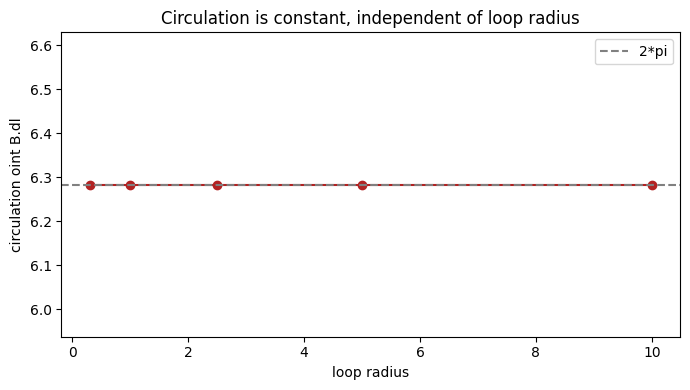

In [5]:
circ_exact = isp.wire_circulation_symbolic()
print(f'SymPy exact circulation (any radius): {circ_exact}')

radii = [0.3, 1.0, 2.5, 5.0, 10.0]
circs = [isp.wire_circulation_numeric(radius=r, n_points=200_000) for r in radii]
for r, c in zip(radii, circs):
    print(f'  radius={r:>5.1f}: circulation = {c:.6f}   (2*pi = {2*np.pi:.6f})')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(radii, circs, 'o-', color='firebrick')
ax.axhline(2*np.pi, color='gray', ls='--', label='2*pi')
ax.set_xlabel('loop radius'); ax.set_ylabel('circulation oint B.dl')
ax.set_title('Circulation is constant, independent of loop radius')
ax.legend()
plt.tight_layout()
plt.savefig('irrotational_solenoidal_circulation.png', dpi=100, bbox_inches='tight')
plt.show()


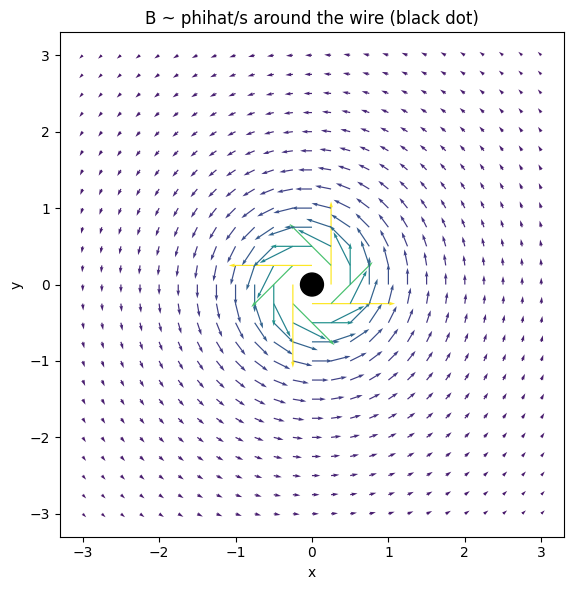

In [6]:
# visualize: the B field direction around the wire (quiver), showing it
# curls around the wire even though its pointwise curl is zero everywhere
# plotted (the wire itself, at the origin, is excluded)
yy, xx = np.mgrid[-3:3:25j, -3:3:25j]
s2 = np.where(xx**2 + yy**2 > 0.15**2, xx**2 + yy**2, np.inf)   # avoid /0 before masking
mask = np.isfinite(s2)
Bx, By = np.where(mask, -yy/s2, 0), np.where(mask, xx/s2, 0)

fig, ax = plt.subplots(figsize=(6, 6))
ax.quiver(xx, yy, Bx, By, np.sqrt(Bx**2+By**2), cmap='viridis')
circle = plt.Circle((0, 0), 0.15, color='black')
ax.add_patch(circle)
ax.set_aspect('equal')
ax.set_title('B ~ phihat/s around the wire (black dot)')
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.tight_layout()
plt.savefig('irrotational_solenoidal_wire_field.png', dpi=100, bbox_inches='tight')
plt.show()


## 5. Engineering Interpretation

- Sections 1-3's agreement (SymPy exact, torch autograd-exact, C finite
  differences) across three completely independent implementations is the
  actual point: these aren't "trust the theorem," they're "watch three
  different pieces of code discover the same zero."
- Section 4 is the useful trap: it would be easy to conclude from Sections
  1-2 alone ("curl is zero everywhere we checked") that $\mathbf B$ is
  conservative and path-independent. The circulation check shows that
  conclusion is wrong specifically BECAUSE the domain excludes the wire --
  a hole in the domain is enough to break the usual curl-zero-implies-
  conservative implication, and Ampere's law is the physical
  manifestation of exactly that topological fact.
- The C finite-difference cross-check's residuals (Section 3, typically
  $10^{-9}$-$10^{-11}$) aren't exactly zero the way SymPy's are -- that gap
  IS the finite-difference truncation/roundoff floor, a useful concrete
  number for how "numerically zero" compares to "exactly zero."


## 6. Research Discussion

- `torch_div_curl_at_points`'s Jacobian-trace/antisymmetric-part
  extraction is the same `torch.func.jacrev`+`vmap` machinery
  `dgs.griffiths_1p49_polyglot.torch_divergence_of_A_off_origin` used for
  divergence alone -- this module is the natural place that pattern was
  heading, and a good candidate for factoring into a shared
  `dgs`-wide autograd-vector-calculus utility rather than reimplementing
  Jacobian extraction per module.
- The Helmholtz decomposition (any well-behaved vector field splits into
  an irrotational part plus a solenoidal part) is the theorem THESE two
  example fields are building blocks for, but isn't demonstrated directly
  here -- a natural follow-up: construct a field that's a linear
  combination of both example fields and verify numerically that
  divergence only "sees" the irrotational piece and curl only "sees" the
  solenoidal piece.
- `dgs.electrodynamics`/`griffiths/fields.py` (if either already implements
  vector potential machinery) should be cross-referenced for consistency
  with this module's $\mathbf A=-\ln(s)\hat{\mathbf z}$ convention.


## 7. Possible Experiments

1. Repeat Section 2's pointwise curl check for the irrotational field
   getting arbitrarily close to the origin (shrinking the exclusion
   radius) and watch where the ~0 result starts to degrade numerically --
   a concrete look at how close autograd-exact evaluation can safely get
   to a true singularity in double precision.
2. Build a THIRD example field that is neither purely irrotational nor
   purely solenoidal (e.g. a generic random polynomial vector field) and
   confirm both its curl and divergence are generically nonzero --
   contrast against this notebook's two special cases.
3. Extend the C program to compute the SAME finite-difference curl/div at
   multiple step sizes `h` and plot the O(h^2) convergence rate directly
   (rather than only checking one `h` against torch's exact answer).


## 8. Future Improvements

- `wire_circulation_numeric` uses a simple trapezoidal sum over a
  uniformly-sampled loop; an adaptive quadrature (matching
  `dgs.griffiths_1p49_polyglot`'s MATLAB `integral()` posture) could
  quantify the numeric method's own convergence rate as `n_points` grows.
- The C cross-check currently only samples 3 points per field; extending
  `cross_validate_languages` to a denser grid (with the results plotted,
  not just max-diff reported) would make the finite-difference error's
  spatial structure visible.
